In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

sys.path.insert(0, str(Path.cwd().parent))
from viz_style import apply_style
apply_style()

from MixedEffectsModeling.validation import lobo_mmd

LOBO = Path('./LOBO_Results_mixed')
FIG = LOBO / 'Figures'
FIG.mkdir(parents=True, exist_ok=True)

In [26]:
def _p_to_asterisk(p):
    if p < 0.001:
        return '***'
    if p < 0.01:
        return '**'
    if p < 0.05:
        return '*'
    return ''


def _short_batch_label(batch):
    name, _, num = batch.replace(' et al.', '').partition('_Batch_')
    return f'{name}_{num}' if num else name


def plot_mmd_bar(df, out_path):
    d = df.sort_values('mmd2', ascending=False).reset_index(drop=True)
    labels = [_short_batch_label(b) for b in d['batch']]
    fig, ax = plt.subplots(figsize=(4, 6))
    bars = ax.bar(range(len(d)), d['mmd2'], color='#00C78B')
    y_span = d['mmd2'].max() - d['mmd2'].min()
    for bar, p in zip(bars, d['perm_p']):
        label = _p_to_asterisk(p)
        if not label:
            continue
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, h + 0.01 * y_span, label, ha='center', va='bottom', fontsize=10)
    ax.set_xticks(range(len(d)))
    ax.set_xticklabels(labels, rotation=45, ha='right')
    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_ylabel('MMD$^2$ (held-out HC vs disease)')
    ax.set_xlabel('LOBO batch')
    plt.tight_layout()
    fig.savefig(out_path, bbox_inches='tight')
    return fig


def plot_mmd_direction(df, out_path):
    # p_direction: Mann-Whitney U, D_D (disease-to-HC-mean) > D_H (HC-to-leave-one-out-HC-mean),
    # both distances computed only from this batch's own LOBO-scored held-out samples
    # (lobo_mmd._ref_centroid_direction) -- shown as an asterisk at the midpoint of each row's segment.
    d = df.sort_values('mmd2', ascending=False).reset_index(drop=True)
    labels = [_short_batch_label(b) for b in d['batch']]
    y = np.arange(len(d))
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.hlines(y, d['hc_ref_dist'], d['dis_ref_dist'],
             color=np.where(d['disease_farther'], '#00C78B', '#999999'), linewidth=3)
    ax.scatter(d['hc_ref_dist'], y, color='#A4AFB8', label='held-out HC', zorder=3, s=90, edgecolors='black', linewidth=0.5)
    ax.scatter(d['dis_ref_dist'], y, color='#00C78B', label='disease', zorder=3, s=90, edgecolors='black', linewidth=0.5)
    if 'p_direction' in d.columns:
        xmid = (d['hc_ref_dist'] + d['dis_ref_dist']) / 2
        for yi, xi, p in zip(y, xmid, d['p_direction']):
            label = _p_to_asterisk(p)
            if label:
                ax.text(xi, yi - 0.08, label, ha='center', va='bottom', fontsize=10)
    ax.set_yticks(y)
    ax.set_yticklabels(labels)
    ax.invert_yaxis()
    ax.set_xlabel('Distance from HC reference')
    ax.set_ylabel('LOBO batch')
    ax.legend(frameon=False, loc='upper left', bbox_to_anchor=(1.02, 1.0))
    plt.tight_layout()
    fig.savefig(out_path, bbox_inches='tight')
    return fig

In [27]:
# 0. Raw MMD summary (held-out HC vs held-out disease, per Tier-A batch with n_hc >= lobo_mmd.MIN_N_HC)
# no SHASH correction -- Z_test.npy / cv_zscores.pkl are used exactly as scored
df_raw = lobo_mmd.mmd_summary_cached(force=False, shash=False)
print(df_raw.to_string(index=False))

n_sig_raw = int(((df_raw['perm_p'] < 0.05) & df_raw['disease_farther']).sum())
print(f"\n{n_sig_raw}/{len(df_raw)} batches: MMD significant (p<0.05) AND disease farther "
     f"from the in-fold HC reference than the held-out-HC noise floor. (raw, no SHASH)")

                          batch  n_hc  n_dis     mmd2   perm_p  hc_ref_dist  dis_ref_dist  disease_farther  p_direction
          Ward Z et al._Batch_1   116    224 0.057589 0.000999    125.68612     149.49818             True 2.773268e-13
           Moore et al._Batch_1    71    173 0.000736 0.224775    133.97040     140.50633             True 1.374205e-02
Roskams-Hieter B et al._Batch_2    27     58 0.009790 0.036963    134.93945     148.76776             True 8.358032e-03
       Moufarrej et al._Batch_4    47     39 0.009684 0.058941    126.29049     141.54045             True 1.592133e-03
            Chen et al._Batch_2    31     32 0.024635 0.011988    133.65019     149.49902             True 2.128754e-02
       Moufarrej et al._Batch_1    54     23 0.034273 0.002997    123.00876     133.74019             True 4.275850e-02

4/6 batches: MMD significant (p<0.05) AND disease farther from the in-fold HC reference than the held-out-HC noise floor. (raw, no SHASH)


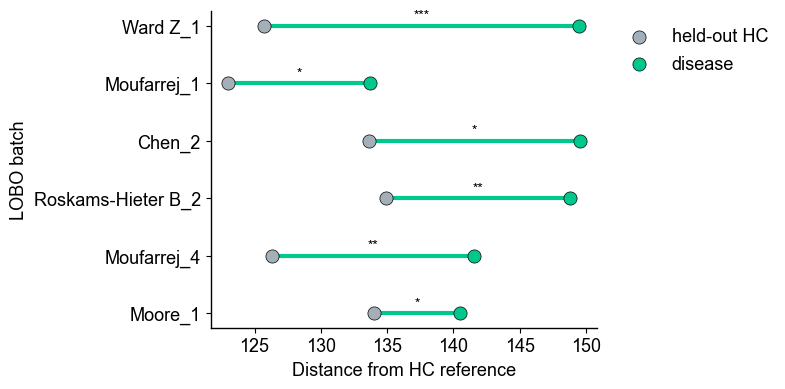

In [28]:
# 1. Raw MMD plots
plot_mmd_bar(df_raw, FIG / 'mmd_bar.png')
plot_mmd_direction(df_raw, FIG / 'mmd_direction.png')

In [29]:
# 2. SHASH-corrected MMD summary -- each gene's already-fit SHASH transform (cv_stats.csv)
# applied to both the LOBO Z and the CV-reference centroid before the comparison
df_shash = lobo_mmd.mmd_summary_cached(force=False, shash=True)
print(df_shash.to_string(index=False))

n_sig_shash = int(((df_shash['perm_p'] < 0.05) & df_shash['disease_farther']).sum())
print(f"\n{n_sig_shash}/{len(df_shash)} batches: MMD significant (p<0.05) AND disease farther "
     f"from the in-fold HC reference than the held-out-HC noise floor. (SHASH-corrected)")

                          batch  n_hc  n_dis     mmd2   perm_p  hc_ref_dist  dis_ref_dist  disease_farther  p_direction
          Ward Z et al._Batch_1   116    224 0.056021 0.000999    126.27508     147.87400             True 1.546074e-11
           Moore et al._Batch_1    71    173 0.000610 0.241758    130.84456     136.37350             True 2.600932e-02
Roskams-Hieter B et al._Batch_2    27     58 0.009409 0.049950    133.44128     146.47780             True 1.310842e-02
       Moufarrej et al._Batch_4    47     39 0.008227 0.085914    125.17438     138.78671             True 3.676126e-03
            Chen et al._Batch_2    31     32 0.023517 0.015984    131.69867     144.90341             True 2.586549e-02
       Moufarrej et al._Batch_1    54     23 0.033363 0.005994    123.20917     132.40370             True 5.764563e-02

4/6 batches: MMD significant (p<0.05) AND disease farther from the in-fold HC reference than the held-out-HC noise floor. (SHASH-corrected)


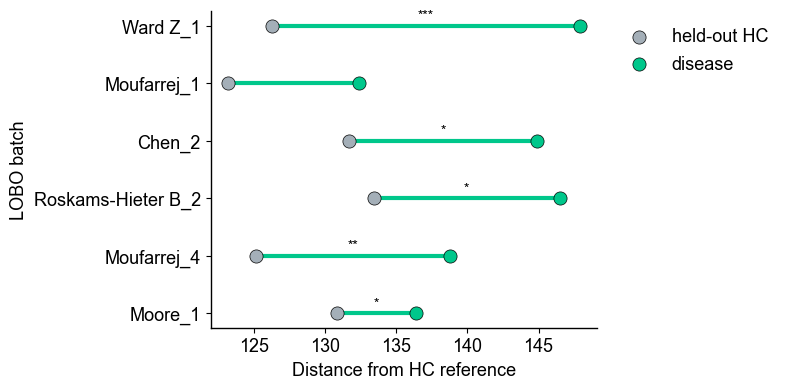

In [30]:
# 3. SHASH-corrected MMD plots
plot_mmd_bar(df_shash, FIG / 'mmd_bar_shash.png')
plot_mmd_direction(df_shash, FIG / 'mmd_direction_shash.png')

In [31]:
# 4. Raw vs SHASH-corrected, side by side -- does the raw-scale call survive de-skewing?
cmp = df_raw.merge(df_shash, on='batch', suffixes=('_raw', '_shash'))
cmp['sig_raw'] = (cmp['perm_p_raw'] < 0.05) & cmp['disease_farther_raw']
cmp['sig_shash'] = (cmp['perm_p_shash'] < 0.05) & cmp['disease_farther_shash']
print(cmp[['batch', 'mmd2_raw', 'perm_p_raw', 'sig_raw', 'mmd2_shash', 'perm_p_shash', 'sig_shash']].to_string(index=False))
print(f"\nagree (both sig or both not): {(cmp['sig_raw'] == cmp['sig_shash']).sum()}/{len(cmp)}")

                          batch  mmd2_raw  perm_p_raw  sig_raw  mmd2_shash  perm_p_shash  sig_shash
          Ward Z et al._Batch_1  0.057589    0.000999     True    0.056021      0.000999       True
           Moore et al._Batch_1  0.000736    0.224775    False    0.000610      0.241758      False
Roskams-Hieter B et al._Batch_2  0.009790    0.036963     True    0.009409      0.049950       True
       Moufarrej et al._Batch_4  0.009684    0.058941    False    0.008227      0.085914      False
            Chen et al._Batch_2  0.024635    0.011988     True    0.023517      0.015984       True
       Moufarrej et al._Batch_1  0.034273    0.002997     True    0.033363      0.005994       True

agree (both sig or both not): 6/6


In [32]:
from MixedEffectsModeling.validation.lobo_engine import compute_ood

compute_ood()

Chang et al._Batch_1                     n_test=  30  removed_OOD=  9 (30.0%)
Chang et al._Batch_11                    n_test=  35  removed_OOD=  1 (2.9%)
Chang et al._Batch_2                     n_test=  37  removed_OOD=  0 (0.0%)
Chang et al._Batch_3                     n_test=  30  removed_OOD=  1 (3.3%)
Chang et al._Batch_4                     n_test=  33  removed_OOD=  0 (0.0%)
Chang et al._Batch_5                     n_test=  25  removed_OOD=  0 (0.0%)
Chen et al._Batch_2                      n_test=  63  removed_OOD=  8 (12.7%)
Gardella et al._Batch_1                  n_test=  30  removed_OOD=  0 (0.0%)
Gardella et al._Batch_3                  n_test=  14  removed_OOD=  1 (7.1%)
Gardella et al._Batch_4                  n_test=  46  removed_OOD=  1 (2.2%)
Gardella et al._Batch_5                  n_test=  32  removed_OOD=  0 (0.0%)
Gardella et al._Batch_7                  n_test=  17  removed_OOD=  0 (0.0%)
Moore et al._Batch_1                     n_test= 244  removed_OOD= 16 (6.6

In [33]:
# OOD-filtered MMD, raw and SHASH-corrected
df_ood = lobo_mmd.mmd_summary_cached(force=False, shash=False, ood_filter=True)
df_shash_ood = lobo_mmd.mmd_summary_cached(force=False, shash=True, ood_filter=True)

for label, d in [('ood', df_ood), ('shash+ood', df_shash_ood)]:
    n_sig = int(((d['perm_p'] < 0.05) & d['disease_farther']).sum())
    print(f"[{label}] {n_sig}/{len(d)} batches significant (p<0.05) AND disease farther")
print()
print(df_shash_ood.to_string(index=False))

[ood] 4/6 batches significant (p<0.05) AND disease farther
[shash+ood] 4/6 batches significant (p<0.05) AND disease farther

                          batch  n_hc  n_dis      mmd2   perm_p  hc_ref_dist  dis_ref_dist  disease_farther  p_direction
          Ward Z et al._Batch_1   105    190  0.054022 0.000999   127.696470     146.35513             True 1.124919e-08
           Moore et al._Batch_1    67    161 -0.000164 0.370629   129.995360     135.15332             True 3.173998e-02
Roskams-Hieter B et al._Batch_2    26     57  0.010340 0.042957   133.123080     145.78240             True 1.308106e-02
       Moufarrej et al._Batch_4    42     30  0.006066 0.152847   124.415924     135.66383             True 1.315558e-02
            Chen et al._Batch_2    27     28  0.028460 0.007992   128.383010     143.19185             True 1.730456e-02
       Moufarrej et al._Batch_1    47     18  0.035657 0.010989   122.050350     135.46107             True 3.183470e-02


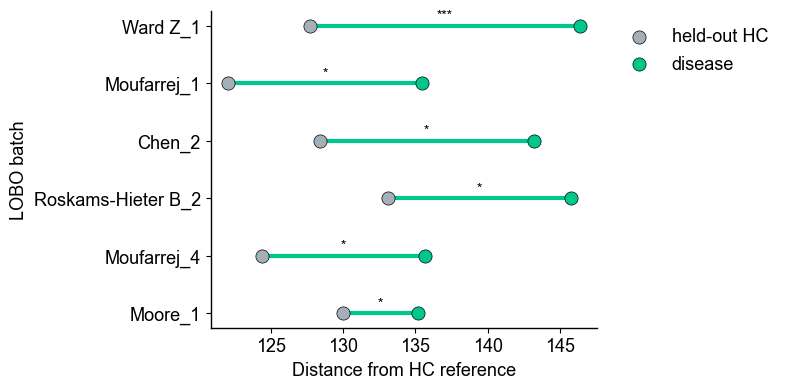

In [34]:
# shash+ood plots (the most rigorous variant: batch-refit + SHASH-decorrelated + extrapolation-flagged)
plot_mmd_bar(df_shash_ood, FIG / 'mmd_bar_shash_ood.png')
plot_mmd_direction(df_shash_ood, FIG / 'mmd_direction_shash_ood.png')

In [35]:
# All 4 variants side by side -- does the raw-scale call survive de-skewing AND extrapolation-flagging?
variants = {'raw': df_raw, 'shash': df_shash, 'ood': df_ood, 'shash_ood': df_shash_ood}
sig = pd.DataFrame({name: (d.set_index('batch')['perm_p'] < 0.05) & d.set_index('batch')['disease_farther']
                    for name, d in variants.items()})
mmd2 = pd.DataFrame({name: d.set_index('batch')['mmd2'] for name, d in variants.items()})

print('significant (p<0.05) AND disease farther, per variant:')
print(sig.to_string())
print(f"\nagree across all 4 variants: {(sig.nunique(axis=1) == 1).sum()}/{len(sig)} batches")
print('\nmmd2 by variant:')
print(mmd2.round(4).to_string())

significant (p<0.05) AND disease farther, per variant:
                                   raw  shash    ood  shash_ood
batch                                                          
Ward Z et al._Batch_1             True   True   True       True
Moore et al._Batch_1             False  False  False      False
Roskams-Hieter B et al._Batch_2   True   True   True       True
Moufarrej et al._Batch_4         False  False  False      False
Chen et al._Batch_2               True   True   True       True
Moufarrej et al._Batch_1          True   True   True       True

agree across all 4 variants: 6/6 batches

mmd2 by variant:
                                    raw   shash     ood  shash_ood
batch                                                             
Ward Z et al._Batch_1            0.0576  0.0560  0.0552     0.0540
Moore et al._Batch_1             0.0007  0.0006  0.0001    -0.0002
Roskams-Hieter B et al._Batch_2  0.0098  0.0094  0.0105     0.0103
Moufarrej et al._Batch_4         0.009

In [36]:
# 5. Batch-matched per-sample deviation (supporting). MMD above is a distribution-level distance;
# this asks the same question one sample at a time. Each batch's held-out HC and its disease samples
# are scored by the SAME LOBO engine (that batch withheld), so null and observation share batch and
# model. n_sig = BH-significant genes in a single sample; AUC = P(a disease sample deviates more
# than an HC sample from the same batch), 0.5 being no signal.
import json
import pickle

import seaborn as sns
from scipy.stats import mannwhitneyu, norm

import MixedEffectsModeling.config as config
from MixedEffectsModeling.core.calibration import bh_fdr_reject
from MixedEffectsModeling.core.shash import load_shash_params, shash_correct_matrix

FDR_Q, Z_CAP = 0.05, 10.0
NSIG_PATH = LOBO / 'lobo_nsig.csv'
lobo_meta = sorted(LOBO.glob('*/meta.json'))

if NSIG_PATH.exists():
    nsig = pd.read_csv(NSIG_PATH)
else:
    genes = pickle.load(open(lobo_meta[0].parent / 'gene_names.pkl', 'rb'))
    params = load_shash_params(config.CV_MIXED_DIR / 'cv_stats.csv')
    rows = []
    for p in lobo_meta:
        m = json.load(open(p))
        Zb = np.nan_to_num(np.load(p.parent / 'Z_test.npy').astype(np.float32), nan=0.0)
        Zb = np.clip(shash_correct_matrix(Zb, genes, params), -Z_CAP, Z_CAP)
        ns = [int(bh_fdr_reject(r, q=FDR_Q).sum()) for r in 2 * norm.sf(np.abs(Zb))]
        rows += [(m['batch_id'], nm, bool(hc), v)
                 for nm, hc, v in zip(m['test_names'], m['test_is_hc'], ns)]
    nsig = pd.DataFrame(rows, columns=['batch', 'sample', 'is_hc', 'n_sig'])
    nsig.to_csv(NSIG_PATH, index=False)

rows = []
for b, g in nsig.groupby('batch'):
    h = g.loc[g['is_hc'], 'n_sig'].values
    d = g.loc[~g['is_hc'], 'n_sig'].values
    if len(h) == 0 or len(d) == 0:
        continue
    u, pu = mannwhitneyu(d, h, alternative='greater')
    rows.append(dict(batch=b, n_hc=len(h), n_dis=len(d), hc_med=np.median(h), dis_med=np.median(d),
                     auc=u / (len(d) * len(h)), mw_p=pu))
nsig_stats = pd.DataFrame(rows).sort_values('auc', ascending=False)
nsig_stats.to_csv(LOBO / 'batch_matched_nsig_stats.csv', index=False)

# same test on true nulls: HC vs the rest of its own batch's HC, must stay at or under 0.05
fp = [((np.delete(h, i) >= h[i]).sum() + 1) / len(h)
      for _, g in nsig.groupby('batch')
      for h in [g.loc[g['is_hc'], 'n_sig'].values] if len(h) >= 19
      for i in range(len(h))]

print(f"batches with both HC and disease: {len(nsig_stats)}  "
      f"AUC>0.5: {(nsig_stats['auc'] > 0.5).sum()}  "
      f"Mann-Whitney p<0.05: {(nsig_stats['mw_p'] < 0.05).sum()}")
print(f"HC-vs-HC leave-one-out false-positive rate: {np.mean(np.array(fp) < 0.05):.4f} "
      f"(target 0.05, n={len(fp)})\n")
print(nsig_stats.to_string(index=False, float_format=lambda v: f'{v:.4f}'))

batches with both HC and disease: 18  AUC>0.5: 17  Mann-Whitney p<0.05: 11
HC-vs-HC leave-one-out false-positive rate: 0.0226 (target 0.05, n=532)

                          batch  n_hc  n_dis  hc_med  dis_med    auc   mw_p
       Reggiardo et al._Batch_1    17      6  0.0000  40.5000 0.9510 0.0005
          Chang et al._Batch_11    12     23  0.0000   3.0000 0.9185 0.0000
           Moore et al._Batch_1    71    173  1.0000   8.0000 0.8843 0.0000
Roskams-Hieter B et al._Batch_2    27     58  0.0000   5.5000 0.8586 0.0000
          Ward Z et al._Batch_1   116    224  0.0000   1.0000 0.8067 0.0000
           Chang et al._Batch_4     9     24  0.0000   2.0000 0.7870 0.0041
       Moufarrej et al._Batch_4    47     39  1.0000   6.0000 0.7297 0.0001
            Chen et al._Batch_2    31     32  0.0000   4.0000 0.7152 0.0010
           Chang et al._Batch_5    14     11  0.0000   0.0000 0.6818 0.0092
           Chang et al._Batch_2     9     28  0.0000   0.0000 0.6528 0.0523
        Gardella

In [38]:
# 6. Batch-matched null vs observation, and the within-batch effect size
fig, axes = plt.subplots(1, 2, figsize=(14, 8))

order = nsig_stats.sort_values('auc')['batch'].tolist()
plot = nsig[nsig['batch'].isin(order)].copy()
plot['group'] = np.where(plot['is_hc'], 'HC (held-out)', 'Disease')
labels = [_short_batch_label(b) for b in order]

sns.stripplot(data=plot, y='batch', x='n_sig', hue='group', order=order,
              hue_order=['HC (held-out)', 'Disease'], palette=['#8c8c8c', '#2a6099'],
              dodge=True, orient='h', size=3, alpha=0.6, jitter=0.25, ax=axes[0])
axes[0].set_xscale('symlog')
axes[0].set_xlim(left=-0.1)
axes[0].set_yticklabels(labels)
axes[0].set_xlabel('BH-significant genes per sample (q=0.05)')
axes[0].set_ylabel('')
axes[0].set_title('Batch-matched null and observation\n(same batch, same LOBO engine)')
axes[0].legend(frameon=False, fontsize=8, loc='lower right')

d = nsig_stats.sort_values('auc')
axes[1].hlines(range(len(d)), 0.5, d['auc'], color='#cccccc', lw=1.2, zorder=1)
axes[1].scatter(d['auc'], range(len(d)), s=np.clip(d['n_dis'], 10, 120),
                color=np.where(d['mw_p'] < 0.05, '#2a6099', '#aec6e8'), zorder=3)
axes[1].axvline(0.5, color='#d64545', ls='--', lw=1.2)
axes[1].text(0.5, len(d) - 0.4, ' no signal', color='#d64545', fontsize=8, ha='left')
axes[1].set_yticks(range(len(d)))
axes[1].set_yticklabels([f"{_short_batch_label(b)} {_p_to_asterisk(p)}"
                         for b, p in zip(d['batch'], d['mw_p'])], fontsize=8)
axes[1].set_xlabel('AUC: P(disease deviates more than HC, same batch)')
axes[1].set_title('Within-batch effect size\n(point size = n disease; filled = p<0.05)')

plt.tight_layout()
fig.savefig(FIG / 'batch_matched_nsig.png', bbox_inches='tight')

/tmp/ipykernel_131852/837038420.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_yticklabels(labels)
